# Precipitations

This notebook opens gridded Global Precipitation Climatology Centre monthly precipitation dataset downloaded from https://psl.noaa.gov/data/gridded/data.gpcc.html . A simple function is defined to get the precipitation for each sediment sapmle latitude-longitude couple.

In [1]:
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
import xarray as xr

In [2]:
folder_name = "inputs\precip.mon.ltm.1991-2020.nc"
ds = nc.Dataset(folder_name)
ds.variables.keys()

dict_keys(['lat', 'lon', 'time', 'climatology_bounds', 'precip', 'valid_yr_count'])

In [3]:
parameters = ['lat', 'lon', 'time', 'climatology_bounds', 'precip', 'valid_yr_count']

In [4]:
for param in ds.variables.keys():
    var = ds.variables[param]
    print(f"\n{param}:", f"  long_name: {getattr(var, 'long_name', 'N/A')}",f"  units: {getattr(var, 'units', 'N/A')}",f"  standard_name: {getattr(var, 'standard_name', 'N/A')}")



lat:   long_name: Latitude   units: degrees_north   standard_name: latitude

lon:   long_name: Longitude   units: degrees_east   standard_name: longitude

time:   long_name: Time   units: days since 1800-1-1 00:00:0.0   standard_name: time

climatology_bounds:   long_name: Climate Time Boundaries   units: days since 1800-1-1 00:00:0.0   standard_name: N/A

precip:   long_name: Long Term Mean Average Monthly Rate of Precipitation   units: mm/day   standard_name: N/A

valid_yr_count:   long_name: count of non-missing values used in mean   units: N/A   standard_name: N/A


In [5]:
ds = xr.open_dataset("inputs\precip.mon.ltm.1991-2020.nc", decode_times=False)

# Average over all 567 months -> one value per lat/lon
precip_mean = ds["precip"].mean(dim="time")

df = precip_mean.to_dataframe().reset_index()[["lat", "lon", "precip"]].dropna()
print(df.head())
df.to_csv("inputs\\precip_mean.csv", index=False)

     lat    lon    precip
0 -88.75   1.25  0.290710
1 -88.75   3.75  0.282620
2 -88.75   6.25  0.282080
3 -88.75   8.75  0.270768
4 -88.75  11.25  0.265033


In [6]:
lats = df['lat']
lons = df['lon']
precip = df['precip']

In [11]:
# Sample points dataset
data_points = pd.read_csv('..\\0.1 MP abundance data collection\FINAL gridded concentrations.csv')
data_points

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1
...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1


In [12]:
latitudes_data  = np.array(data_points["Lat_center"], dtype=float)
longitudes_data = np.array(data_points["Lon_center"], dtype=float)

points_data = list(zip(latitudes_data, longitudes_data))
# Format: (latitude, longitude, "Label")

lats_data   = [p[0] for p in points_data]
lons_data   = [p[1] for p in points_data]

lats_data = np.array(lats_data)
lons_data = np.array(lons_data)

In [13]:
print('lons',lons.min(), lons.max())
print('lats',lats.min(), lats.max())

lons 1.25 358.75
lats -88.75 88.75


In [14]:
def get_precipitations(lat_query, lon_query, output_storage, df_precip):
    """
    Returns distance to nearest coastline in km for an ocean point.
    Uncertainty: ~1 km at any given point.
    """
    lat_idx = np.argmin(np.abs(df_precip['lat'] - lat_query))
    lon_idx = np.argmin(np.abs(df_precip['lon'] - lon_query))

    for row in range(len(df_precip)):

        if df_precip['lat'].iloc[row] == df_precip['lat'].iloc[lat_idx] and df_precip['lon'].iloc[row] == df_precip['lon'].iloc[lon_idx] :

            val = df_precip['precip'].iloc[row]

            if np.ma.is_masked(val) or np.isnan(float(val)):
                print(f"({lat_query}, {lon_query}) → no data")
                output_storage.append(np.nan)
                return None

            val = float(val)
            print(f"Query        : {lat_query}°N, {lon_query}°E")
            print(f"Nearest cell : {float(df_precip['lat'].iloc[row]):.4f}°N, {float(df_precip['lon'].iloc[row]):.4f}°E")
            print(f"Mean Precipitations over 1991-2021: {val:.2f} mm")

            if val ==0.0:
                print('ERRROROROROROE')

            output_storage.append(val) 

    return val

In [15]:
out=[]
get_precipitations(lats_data[0], lons_data[0], out, df)

Query        : -74.5°N, 163.5°E
Nearest cell : -73.7500°N, 163.7500°E
Mean Precipitations over 1991-2021: 0.69 mm


0.6916841864585876

In [16]:
out=[]
for i in range(len(lats_data)):
    get_precipitations(lats_data[i], lons_data[i], out, df)

Query        : -74.5°N, 163.5°E
Nearest cell : -73.7500°N, 163.7500°E
Mean Precipitations over 1991-2021: 0.69 mm
Query        : -74.5°N, 164.5°E
Nearest cell : -73.7500°N, 163.7500°E
Mean Precipitations over 1991-2021: 0.69 mm
Query        : -42.5°N, 147.5°E
Nearest cell : -43.7500°N, 146.2500°E
Mean Precipitations over 1991-2021: 4.08 mm
Query        : -38.5°N, 144.5°E
Nearest cell : -38.7500°N, 143.7500°E
Mean Precipitations over 1991-2021: 2.02 mm
Query        : -35.5°N, 138.5°E
Nearest cell : -36.2500°N, 138.7500°E
Mean Precipitations over 1991-2021: 1.44 mm
Query        : -34.5°N, 150.5°E
Nearest cell : -33.7500°N, 151.2500°E
Mean Precipitations over 1991-2021: 2.50 mm
Query        : -23.5°N, -43.5°E
Nearest cell : -23.7500°N, 1.2500°E
Mean Precipitations over 1991-2021: 0.23 mm
Query        : -22.5°N, -43.5°E
Nearest cell : -23.7500°N, 1.2500°E
Mean Precipitations over 1991-2021: 0.23 mm
Query        : -6.5°N, 112.5°E
Nearest cell : -6.2500°N, 111.2500°E
Mean Precipitations over

In [17]:
out
output = pd.DataFrame(out, columns=['Precipitations'])

data_points['Mean Precipitations over 1991-2021'] = output['Precipitations']
data_points

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,Mean Precipitations over 1991-2021
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1,0.691684
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10,0.691684
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1,4.083358
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1,2.017438
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1,1.439654
...,...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1,1.922102
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1,1.922102
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1,1.922102
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1,1.662682


In [18]:
np.min(data_points['Mean Precipitations over 1991-2021'])

np.float64(0.22585803270339966)

In [19]:
data_points.to_csv('outputs\Precipitations.csv', index=False)

# Statistics

In [20]:
# Normalize data for statistics
data_points_copy = data_points.copy()
data_points_copy['Mean Precipitations over 1991-2021'] = data_points_copy['Mean Precipitations over 1991-2021'].apply(pd.to_numeric, errors='coerce').fillna(0)

cols_to_normalize = ['MEAN MP stock (g/m2) in 2021',
                     'Mean Precipitations over 1991-2021']

scaler = MinMaxScaler()
data_points_copy[cols_to_normalize] = scaler.fit_transform(data_points_copy[cols_to_normalize])

# Divide fibers from fragments
data_points_fib = data_points_copy[data_points_copy["Shape"] == "Fibers"]
data_points_frg = data_points_copy[data_points_copy["Shape"] == "Fragments"]


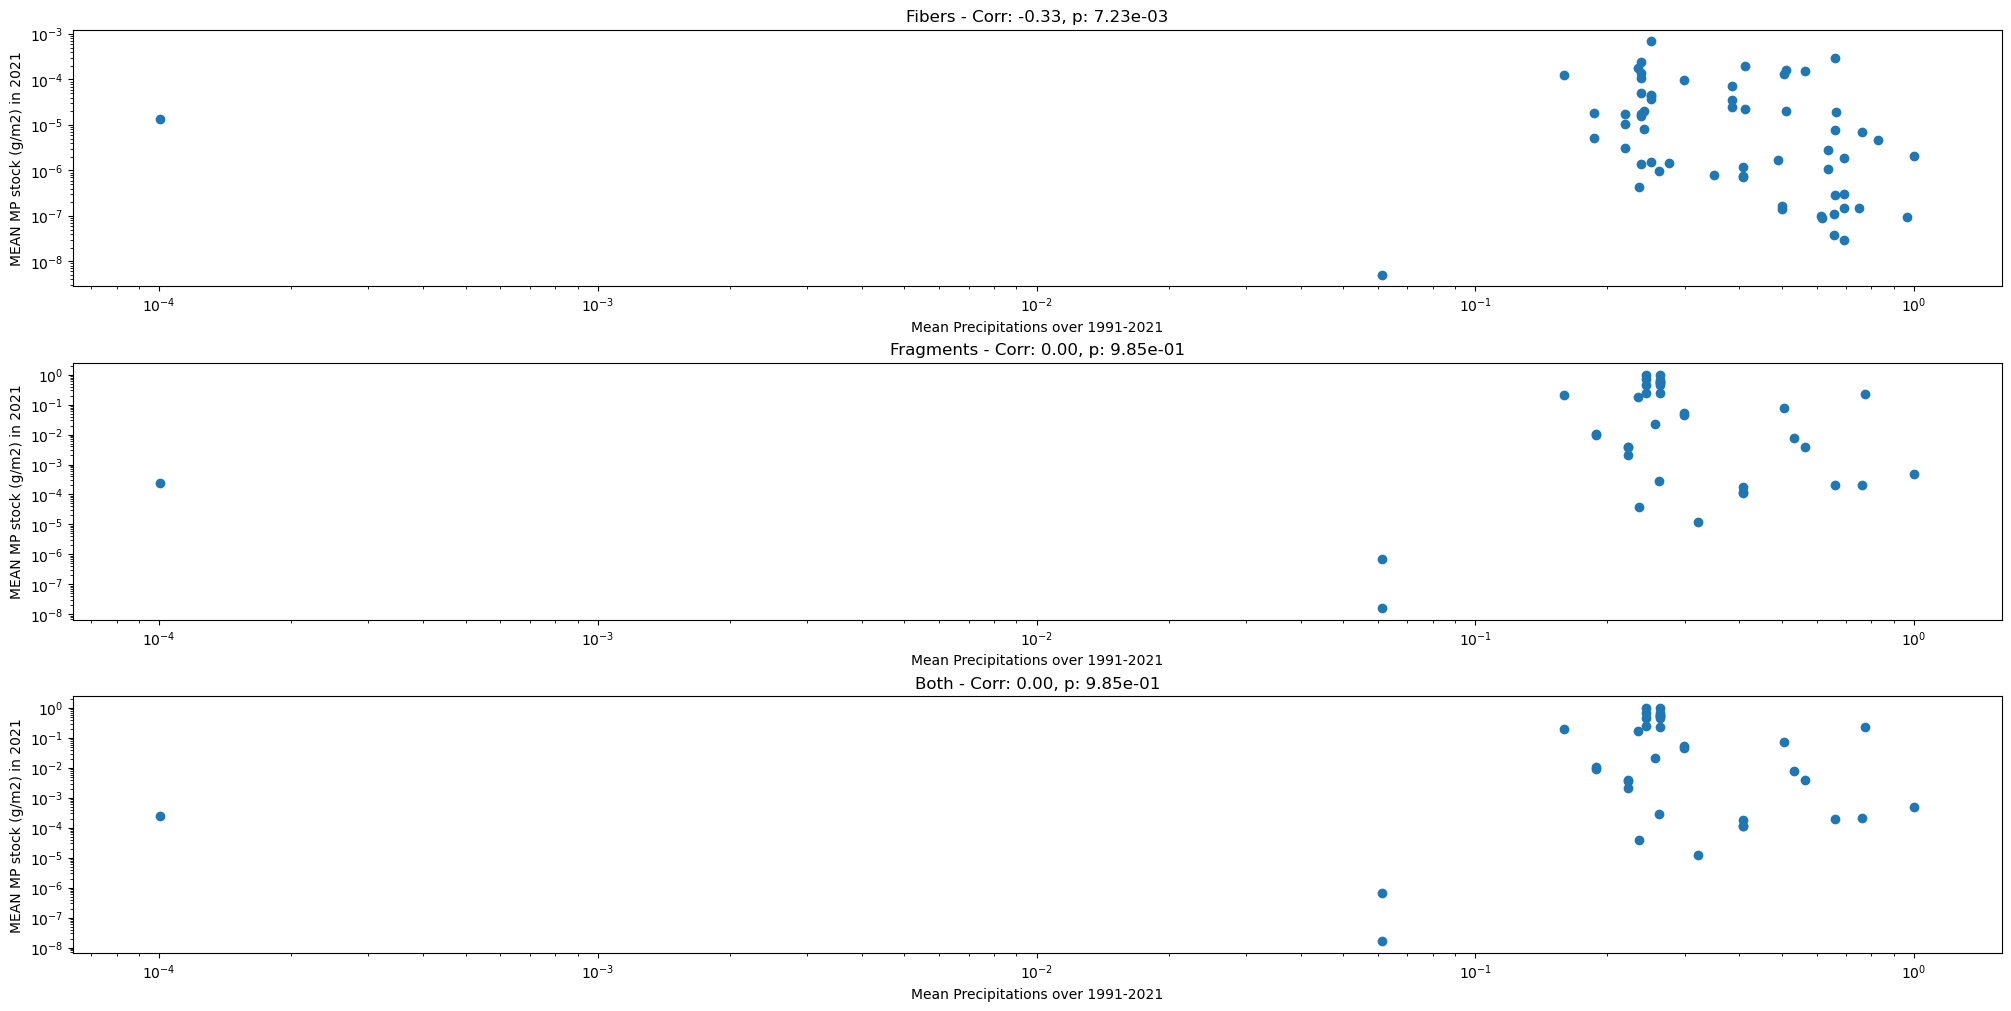

In [21]:
fig, axs = plt.subplots(3, 1, layout="constrained", figsize=(20, 10))
ax1, ax2, ax3 = axs.flatten()

cmap = plt.colormaps['plasma']

spearman_results = []

# Fibers
x = data_points_fib['Mean Precipitations over 1991-2021']
y = data_points_fib['MEAN MP stock (g/m2) in 2021']

mask = np.isfinite(x) & np.isfinite(y)
spearman_stock = stats.spearmanr(x[mask], y[mask])

spearman_results.append(['Mean Precipitations over 1991-2021 Fibers stock', spearman_stock[0], spearman_stock[1]])

ax1.scatter(data_points_fib['Mean Precipitations over 1991-2021'], data_points_fib['MEAN MP stock (g/m2) in 2021'])
ax1.set_title(f"Fibers - Corr: {spearman_stock[0]:.2f}, p: {spearman_stock[1]:.2e}")

# Fragments
x = data_points_frg['Mean Precipitations over 1991-2021']
y = data_points_frg['MEAN MP stock (g/m2) in 2021']

mask = np.isfinite(x) & np.isfinite(y)
spearman_stock = stats.spearmanr(x[mask], y[mask])

spearman_results.append(['Mean Precipitations over 1991-2021 Fragments stock', spearman_stock[0], spearman_stock[1]])

ax2.scatter(data_points_frg['Mean Precipitations over 1991-2021'], data_points_frg['MEAN MP stock (g/m2) in 2021'])
ax2.set_title(f"Fragments - Corr: {spearman_stock[0]:.2f}, p: {spearman_stock[1]:.2e}")

# Both
x = data_points_frg['Mean Precipitations over 1991-2021']
y = data_points_frg['MEAN MP stock (g/m2) in 2021']

mask = np.isfinite(x) & np.isfinite(y)
spearman_stock = stats.spearmanr(x[mask], y[mask])

spearman_results.append(['Mean Precipitations over 1991-2021 Both together stock', spearman_stock[0], spearman_stock[1]])

ax3.scatter(data_points_frg['Mean Precipitations over 1991-2021'], data_points_frg['MEAN MP stock (g/m2) in 2021'])
ax3.set_title(f"Both - Corr: {spearman_stock[0]:.2f}, p: {spearman_stock[1]:.2e}")

# Labels

for ax in axs.flatten():
    ax.set_xlabel('Mean Precipitations over 1991-2021')
    ax.set_ylabel('MEAN MP stock (g/m2) in 2021')
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.show()

In [68]:
results_stats = pd.DataFrame(spearman_results, columns=["Parameter", "Spearman Correlation", "Spearman p-value"])
results_stats

,Parameter,Spearman Correlation,Spearman p-value
0,Mean Precipitations over 1991-2021 Fibers stock,-0.354281,0.003786
1,Mean Precipitations over 1991-2021 Fragments s...,-0.007818,0.961811
2,Mean Precipitations over 1991-2021 Both togeth...,-0.007818,0.961811
